# LightGBM vs XGBoost — Daily Attendance Forecast Comparison
## PortAventura World

**Objective:** Forecast daily attendance for **July 26 – August 23, 2022** (29 days) using both LightGBM and XGBoost regressors, trained on the same historical daily data with calendar, weather, COVID, lag, and rolling features.

**Approach:** Recursive one-step-ahead forecasting — each predicted day is appended to history before computing features for the next day.

**Goal:** Compare the performance of LightGBM and XGBoost side-by-side.

In [1]:
# ============================================================
# CELL 1 — IMPORTS & DATA LOADING
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings, os
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

# --- Resolve data directory ---
if os.path.exists('final_data/attendance.csv'):
    DATA_DIR = 'final_data'
elif os.path.exists('../final_data/attendance.csv'):
    DATA_DIR = '../final_data'
else:
    raise FileNotFoundError("Cannot find final_data directory")

# --- Load attendance (PortAventura World only) ---
att = pd.read_csv(f'{DATA_DIR}/attendance.csv')
att['USAGE_DATE'] = pd.to_datetime(att['USAGE_DATE'])

pa = att[att['FACILITY_NAME'] == 'PortAventura World'].copy()
pa = pa.rename(columns={'USAGE_DATE': 'date', 'attendance': 'y'})
pa = pa[['date', 'y']].sort_values('date').reset_index(drop=True)

print(f"PortAventura daily attendance: {len(pa)} rows")
print(f"Date range: {pa['date'].min().date()} → {pa['date'].max().date()}")

# --- Load pre-aggregated daily weather ---
weather = pd.read_csv(f'{DATA_DIR}/merged/merged_weather_waiting_daily.csv')
weather['date'] = pd.to_datetime(weather['date'])

# Keep only the weather columns we need
weather_cols_keep = [
    'date', 'temp_mean', 'temp_min', 'temp_max', 'feels_like_mean',
    'humidity_mean', 'wind_speed_mean', 'wind_speed_max',
    'pressure_mean', 'clouds_mean', 'rain_total', 'snow_total',
    'has_rain', 'has_snow'
]
weather = weather[weather_cols_keep]

print(f"\nWeather daily: {len(weather)} rows")
print(f"Date range: {weather['date'].min().date()} → {weather['date'].max().date()}")

pa.head()

PortAventura daily attendance: 1182 rows
Date range: 2018-06-01 → 2022-07-26

Weather daily: 1691 rows
Date range: 2018-01-01 → 2022-08-18


,date,y
0,2018-06-01,46804
1,2018-06-02,57940
2,2018-06-03,44365
3,2018-06-04,37617
4,2018-06-05,32438


In [2]:
# ============================================================
# CELL 2 — FEATURE ENGINEERING
# ============================================================

# --- Merge attendance + weather ---
df = pa.merge(weather, on='date', how='left')
print(f"Merged dataset: {len(df)} rows, {df.shape[1]} columns")
print(f"Missing weather rows: {df['temp_mean'].isna().sum()}")

# --- Clean negative attendance via interpolation ---
neg_mask = df['y'] < 0
print(f"Replacing {neg_mask.sum()} negative attendance values via interpolation")
df.loc[neg_mask, 'y'] = np.nan
df['y'] = df['y'].interpolate(method='linear')

# --- Calendar features ---
df['day_of_week'] = df['date'].dt.dayofweek          # 0=Mon, 6=Sun
df['month']       = df['date'].dt.month
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['day_of_year'] = df['date'].dt.dayofyear
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
df['year']        = df['date'].dt.year
df['is_summer']   = df['month'].isin([6, 7, 8]).astype(int)
df['is_holiday_season'] = df['month'].isin([6, 7, 8, 12]).astype(int)

# Cyclical encodings
df['dow_sin']   = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']   = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# --- COVID features ---
covid_start = pd.Timestamp('2020-02-01')
covid_end   = pd.Timestamp('2021-06-30')
df['is_covid']    = ((df['date'] >= covid_start) & (df['date'] <= covid_end)).astype(int)
df['is_recovery'] = (df['date'] > covid_end).astype(int)
df['recovery_months'] = np.where(
    df['date'] > covid_end,
    ((df['date'] - covid_end).dt.days / 30.44).clip(upper=12),
    0.0
)

# --- Forward-fill any missing weather ---
weather_num_cols = ['temp_mean', 'temp_min', 'temp_max', 'feels_like_mean',
                    'humidity_mean', 'wind_speed_mean', 'wind_speed_max',
                    'pressure_mean', 'clouds_mean', 'rain_total', 'snow_total']
df[weather_num_cols] = df[weather_num_cols].ffill().bfill()
df['has_rain'] = (df['rain_total'] > 0).astype(int)
df['has_snow'] = (df['snow_total'] > 0).astype(int)

# --- Lag features (shift from original y) ---
df = df.set_index('date').sort_index()
for lag in [7, 14, 28, 365]:
    df[f'lag_{lag}'] = df['y'].shift(lag)

# --- Rolling statistics (shifted by 1 to avoid leakage) ---
for window in [7, 14, 30]:
    df[f'roll_mean_{window}'] = df['y'].shift(1).rolling(window).mean()
    df[f'roll_std_{window}']  = df['y'].shift(1).rolling(window).std()

print(f"\nFinal dataset (before NaN drop): {df.shape}")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")
print(f"NaN rows (from lagging): {df.isna().any(axis=1).sum()}")

# Define feature columns (used throughout)
FEATURE_COLS = [
    # Calendar
    'day_of_week', 'month', 'week_of_year', 'day_of_year', 'is_weekend', 'year',
    'is_summer', 'is_holiday_season',
    'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    # Weather
    'temp_mean', 'temp_min', 'temp_max', 'feels_like_mean',
    'humidity_mean', 'wind_speed_mean', 'pressure_mean', 'clouds_mean',
    'rain_total', 'has_rain',
    # COVID
    'is_covid', 'is_recovery', 'recovery_months',
    # Lags & rolling
    'lag_7', 'lag_14', 'lag_28', 'lag_365',
    'roll_mean_7', 'roll_mean_14', 'roll_mean_30',
    'roll_std_7', 'roll_std_14', 'roll_std_30',
]

print(f"\nFeature columns: {len(FEATURE_COLS)}")
df.tail(3)

Merged dataset: 1182 rows, 15 columns
Missing weather rows: 0
Replacing 37 negative attendance values via interpolation

Final dataset (before NaN drop): (1182, 39)
Date range: 2018-06-01 → 2022-07-26
NaN rows (from lagging): 365

Feature columns: 35


,y,temp_mean,temp_min,temp_max,feels_like_mean,humidity_mean,wind_speed_mean,wind_speed_max,pressure_mean,clouds_mean,...,lag_7,lag_14,lag_28,lag_365,roll_mean_7,roll_std_7,roll_mean_14,roll_std_14,roll_mean_30,roll_std_30
date,,,,,,,,,,,,,,,,,,,,,
2022-07-24,45261.0,24.897917,16.07,32.56,25.453333,68.333333,2.233750,2.92,1016.666667,26.666667,...,40938.0,42301.0,45930.0,20507.0,47728.142857,4000.545189,48082.857143,3631.617183,46673.933333,3894.031666
2022-07-25,53764.0,22.689583,17.51,26.85,22.826667,67.791667,4.442917,6.91,1013.541667,60.583333,...,46808.0,46846.0,47382.0,17566.0,48345.714286,2981.531022,48294.285714,3343.875468,46476.700000,3806.907199
2022-07-26,26391.0,19.101667,15.92,22.48,19.017917,74.666667,3.003750,4.06,1018.750000,76.500000,...,46753.0,53867.0,48350.0,15573.0,49339.428571,3498.050450,48788.428571,3613.663211,46777.900000,4015.525373


In [3]:
# ============================================================
# CELL 3 — TRAIN / TEST SPLIT
# ============================================================

CUTOFF = pd.Timestamp('2022-07-25')   # last day of training data
FORECAST_START = pd.Timestamp('2022-07-26')
FORECAST_END   = pd.Timestamp('2022-08-23')
FORECAST_DAYS  = 29

# Training set: all data up to (and including) July 25
# Drop NaN rows caused by lag_365 (first ~365 days)
train_df = df.loc[:CUTOFF].dropna(subset=FEATURE_COLS).copy()

X_train = train_df[FEATURE_COLS]
y_train = train_df['y']

# Validation split for early stopping: last 60 days of training
VAL_DAYS = 60
val_cutoff = CUTOFF - pd.Timedelta(days=VAL_DAYS)
X_tr  = X_train.loc[:val_cutoff]
y_tr  = y_train.loc[:val_cutoff]
X_val = X_train.loc[val_cutoff + pd.Timedelta(days=1):]
y_val = y_train.loc[val_cutoff + pd.Timedelta(days=1):]

print(f"Training set:    {len(X_train)} rows  ({X_train.index.min().date()} → {X_train.index.max().date()})")
print(f"  ├─ Fit split:  {len(X_tr)} rows")
print(f"  └─ Val split:  {len(X_val)} rows  (last {VAL_DAYS} days for early stopping)")
print(f"\nForecast window: {FORECAST_START.date()} → {FORECAST_END.date()} ({FORECAST_DAYS} days)")

# Actual value for July 26 (the one day we can validate)
actual_jul26 = df.loc[FORECAST_START, 'y'] if FORECAST_START in df.index else None
print(f"Actual attendance on July 26: {actual_jul26:,.0f}" if actual_jul26 else "July 26 actual not available")

Training set:    816 rows  (2019-06-01 → 2022-07-25)
  ├─ Fit split:  756 rows
  └─ Val split:  60 rows  (last 60 days for early stopping)

Forecast window: 2022-07-26 → 2022-08-23 (29 days)
Actual attendance on July 26: 26,391


  XGBoost Training Results
Best iteration: 71
Best validation score (RMSE): 5052
Training residual std: 2,780
Training MAE: 1,978
Training MAPE: 272.45%


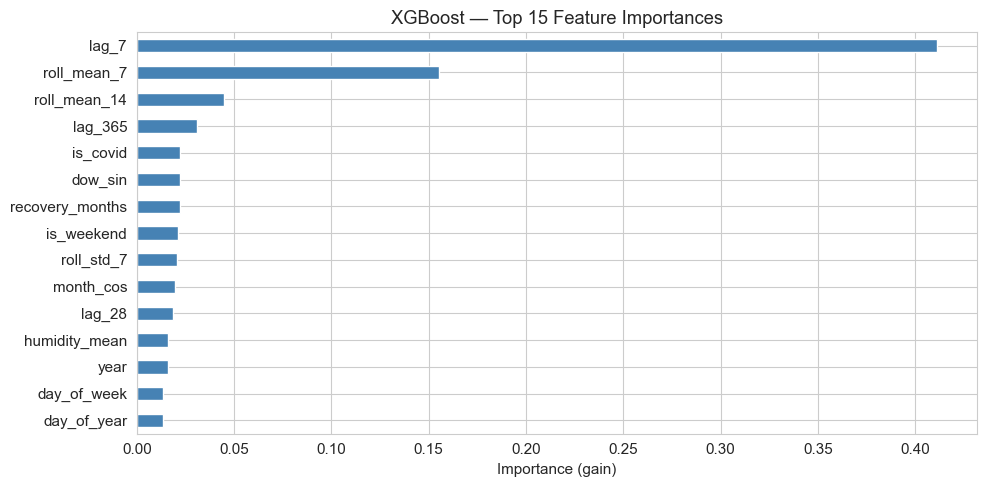

In [4]:
# ============================================================
# CELL 4 — TRAIN XGBOOST MODEL
# ============================================================

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=42,
    early_stopping_rounds=30,
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print("=" * 60)
print("  XGBoost Training Results")
print("=" * 60)
print(f"Best iteration: {xgb_model.best_iteration}")
print(f"Best validation score (RMSE): {xgb_model.best_score:.0f}")

# --- Training residuals ---
xgb_train_pred = xgb_model.predict(X_train)
xgb_train_residuals = y_train.values - xgb_train_pred
xgb_residual_std = np.std(xgb_train_residuals)
print(f"Training residual std: {xgb_residual_std:,.0f}")
print(f"Training MAE: {mean_absolute_error(y_train, xgb_train_pred):,.0f}")
print(f"Training MAPE: {np.mean(np.abs(xgb_train_residuals) / y_train.values) * 100:.2f}%")

# --- Feature importance (top 15) ---
xgb_importances = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
xgb_importances.head(15).plot.barh(ax=ax, color='steelblue')
ax.set_title('XGBoost — Top 15 Feature Importances')
ax.set_xlabel('Importance (gain)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

  LightGBM Training Results
Best iteration: 72
Best validation score (l2): 27830376
Training residual std: 3,345
Training MAE: 2,449
Training MAPE: 305.28%


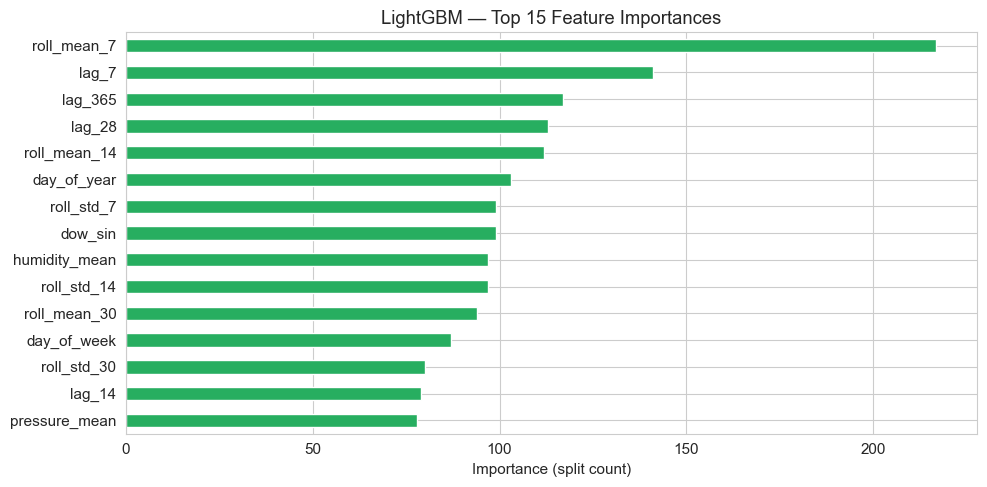

In [5]:
# ============================================================
# CELL 5 — TRAIN LIGHTGBM MODEL
# ============================================================

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=42,
    num_leaves=63,             # 2^max_depth - 1 for comparable complexity
    min_child_samples=10,
    verbosity=-1,
)

lgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=False),
        lgb.log_evaluation(period=0),  # suppress logging
    ],
)

print("=" * 60)
print("  LightGBM Training Results")
print("=" * 60)
print(f"Best iteration: {lgb_model.best_iteration_}")
print(f"Best validation score (l2): {lgb_model.best_score_['valid_0']['l2']:.0f}")

# --- Training residuals ---
lgb_train_pred = lgb_model.predict(X_train)
lgb_train_residuals = y_train.values - lgb_train_pred
lgb_residual_std = np.std(lgb_train_residuals)
print(f"Training residual std: {lgb_residual_std:,.0f}")
print(f"Training MAE: {mean_absolute_error(y_train, lgb_train_pred):,.0f}")
print(f"Training MAPE: {np.mean(np.abs(lgb_train_residuals) / y_train.values) * 100:.2f}%")

# --- Feature importance (top 15) ---
lgb_importances = pd.Series(lgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
lgb_importances.head(15).plot.barh(ax=ax, color='#27ae60')
ax.set_title('LightGBM — Top 15 Feature Importances')
ax.set_xlabel('Importance (split count)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# CELL 6 — RECURSIVE ONE-STEP-AHEAD FORECASTING (BOTH MODELS)
# ============================================================

def recursive_forecast(model, df, weather, CUTOFF, FORECAST_START, FORECAST_END, FEATURE_COLS, covid_start, covid_end):
    """Run recursive one-step-ahead forecast for a given model."""
    weather_indexed = weather.set_index('date')
    history = df.loc[:CUTOFF, 'y'].copy()
    forecast_dates = pd.date_range(FORECAST_START, FORECAST_END, freq='D')
    predictions = []

    for fdate in forecast_dates:
        row = {}
        # --- Calendar features ---
        row['day_of_week'] = fdate.dayofweek
        row['month']       = fdate.month
        row['week_of_year'] = fdate.isocalendar().week
        row['day_of_year'] = fdate.dayofyear
        row['is_weekend']  = int(fdate.dayofweek >= 5)
        row['year']        = fdate.year
        row['is_summer']   = int(fdate.month in [6, 7, 8])
        row['is_holiday_season'] = int(fdate.month in [6, 7, 8, 12])
        row['dow_sin']   = np.sin(2 * np.pi * fdate.dayofweek / 7)
        row['dow_cos']   = np.cos(2 * np.pi * fdate.dayofweek / 7)
        row['month_sin'] = np.sin(2 * np.pi * fdate.month / 12)
        row['month_cos'] = np.cos(2 * np.pi * fdate.month / 12)

        # --- Weather features ---
        if fdate in weather_indexed.index:
            w = weather_indexed.loc[fdate]
            row['temp_mean']       = w['temp_mean']
            row['temp_min']        = w['temp_min']
            row['temp_max']        = w['temp_max']
            row['feels_like_mean'] = w['feels_like_mean']
            row['humidity_mean']   = w['humidity_mean']
            row['wind_speed_mean'] = w['wind_speed_mean']
            row['pressure_mean']   = w['pressure_mean']
            row['clouds_mean']     = w['clouds_mean']
            row['rain_total']      = w['rain_total']
            row['has_rain']        = int(w['rain_total'] > 0)
        else:
            last_w = weather_indexed.iloc[-1]
            for c in ['temp_mean','temp_min','temp_max','feels_like_mean',
                       'humidity_mean','wind_speed_mean','pressure_mean',
                       'clouds_mean','rain_total']:
                row[c] = last_w[c]
            row['has_rain'] = int(last_w['rain_total'] > 0)

        # --- COVID features ---
        row['is_covid']    = int(covid_start <= fdate <= covid_end)
        row['is_recovery'] = int(fdate > covid_end)
        row['recovery_months'] = min(((fdate - covid_end).days / 30.44), 12) if fdate > covid_end else 0.0

        # --- Lag features ---
        for lag in [7, 14, 28, 365]:
            lag_date = fdate - pd.Timedelta(days=lag)
            row[f'lag_{lag}'] = history.get(lag_date, np.nan)

        # --- Rolling features ---
        yesterday = fdate - pd.Timedelta(days=1)
        recent = history.loc[:yesterday]
        row['roll_mean_7']  = recent.iloc[-7:].mean()  if len(recent) >= 7  else recent.mean()
        row['roll_mean_14'] = recent.iloc[-14:].mean() if len(recent) >= 14 else recent.mean()
        row['roll_mean_30'] = recent.iloc[-30:].mean() if len(recent) >= 30 else recent.mean()
        row['roll_std_7']   = recent.iloc[-7:].std()   if len(recent) >= 7  else recent.std()
        row['roll_std_14']  = recent.iloc[-14:].std()  if len(recent) >= 14 else recent.std()
        row['roll_std_30']  = recent.iloc[-30:].std()  if len(recent) >= 30 else recent.std()

        # --- Predict ---
        X_forecast = pd.DataFrame([row])[FEATURE_COLS]
        pred = float(np.clip(model.predict(X_forecast), 0, None)[0])
        predictions.append({'date': fdate, 'predicted': pred})
        history.loc[fdate] = pred

    forecast_df = pd.DataFrame(predictions)
    forecast_df['day_name'] = forecast_df['date'].dt.day_name()
    return forecast_df

# --- Run forecasts for both models ---
print("Running XGBoost recursive forecast...")
xgb_forecast = recursive_forecast(xgb_model, df, weather, CUTOFF, FORECAST_START, FORECAST_END, FEATURE_COLS, covid_start, covid_end)
print("Running LightGBM recursive forecast...")
lgb_forecast = recursive_forecast(lgb_model, df, weather, CUTOFF, FORECAST_START, FORECAST_END, FEATURE_COLS, covid_start, covid_end)

# Add confidence bands
xgb_forecast['lower'] = (xgb_forecast['predicted'] - 1.96 * xgb_residual_std).clip(lower=0)
xgb_forecast['upper'] = xgb_forecast['predicted'] + 1.96 * xgb_residual_std
lgb_forecast['lower'] = (lgb_forecast['predicted'] - 1.96 * lgb_residual_std).clip(lower=0)
lgb_forecast['upper'] = lgb_forecast['predicted'] + 1.96 * lgb_residual_std

print("\nForecasts complete!")
print(f"Forecast period: {xgb_forecast['date'].iloc[0].date()} → {xgb_forecast['date'].iloc[-1].date()}")

Running XGBoost recursive forecast...
Running LightGBM recursive forecast...

Forecasts complete!
Forecast period: 2022-07-26 → 2022-08-23


In [7]:
# ============================================================
# CELL 7 — RESULTS & EVALUATION
# ============================================================

# Print XGBoost results
print("=" * 85)
print("  XGBoost 29-Day Forecast — PortAventura World")
print("=" * 85)
print(f"  {'Date':<14} {'Day':<12} {'Predicted':>12}   {'95% CI Lower':>12}   {'95% CI Upper':>12}")
print("-" * 85)
for _, r in xgb_forecast.iterrows():
    print(f"  {r['date'].strftime('%Y-%m-%d'):<14} {r['day_name']:<12} {r['predicted']:>12,.0f}   {r['lower']:>12,.0f}   {r['upper']:>12,.0f}")
print("=" * 85)
print(f"  Daily average: {xgb_forecast['predicted'].mean():>12,.0f}")
print()

# Print LightGBM results
print("=" * 85)
print("  LightGBM 29-Day Forecast — PortAventura World")
print("=" * 85)
print(f"  {'Date':<14} {'Day':<12} {'Predicted':>12}   {'95% CI Lower':>12}   {'95% CI Upper':>12}")
print("-" * 85)
for _, r in lgb_forecast.iterrows():
    print(f"  {r['date'].strftime('%Y-%m-%d'):<14} {r['day_name']:<12} {r['predicted']:>12,.0f}   {r['lower']:>12,.0f}   {r['upper']:>12,.0f}")
print("=" * 85)
print(f"  Daily average: {lgb_forecast['predicted'].mean():>12,.0f}")
print()

# --- Validation on July 26 ---
if actual_jul26 is not None:
    xgb_pred_jul26 = xgb_forecast.loc[xgb_forecast['date'] == FORECAST_START, 'predicted'].values[0]
    lgb_pred_jul26 = lgb_forecast.loc[lgb_forecast['date'] == FORECAST_START, 'predicted'].values[0]
    xgb_error = actual_jul26 - xgb_pred_jul26
    lgb_error = actual_jul26 - lgb_pred_jul26
    xgb_mape = abs(xgb_error) / actual_jul26 * 100
    lgb_mape = abs(lgb_error) / actual_jul26 * 100

    print("=" * 85)
    print("  Validation on July 26, 2022")
    print("=" * 85)
    print(f"  Actual:                    {actual_jul26:>10,.0f}")
    print(f"  XGBoost Predicted:         {xgb_pred_jul26:>10,.0f}   (Error: {xgb_error:>+10,.0f}, MAPE: {xgb_mape:.2f}%)")
    print(f"  LightGBM Predicted:        {lgb_pred_jul26:>10,.0f}   (Error: {lgb_error:>+10,.0f}, MAPE: {lgb_mape:.2f}%)")
    print("=" * 85)

  XGBoost 29-Day Forecast — PortAventura World
  Date           Day             Predicted   95% CI Lower   95% CI Upper
-------------------------------------------------------------------------------------
  2022-07-26     Tuesday            45,168         39,719         50,618
  2022-07-27     Wednesday          44,845         39,395         50,294
  2022-07-28     Thursday           44,951         39,501         50,400
  2022-07-29     Friday             44,329         38,880         49,779
  2022-07-30     Saturday           52,460         47,011         57,909
  2022-07-31     Sunday             45,359         39,910         50,809
  2022-08-01     Monday             44,423         38,974         49,873
  2022-08-02     Tuesday            43,054         37,604         48,503
  2022-08-03     Wednesday          42,342         36,893         47,792
  2022-08-04     Thursday           41,659         36,209         47,108
  2022-08-05     Friday             45,790         40,341       

In [8]:
# ============================================================
# CELL 8 — TRAINING METRICS COMPARISON
# ============================================================

# Compute comprehensive training metrics for both models
metrics = {
    'Model': ['XGBoost', 'LightGBM'],
    'Training MAE': [
        mean_absolute_error(y_train, xgb_train_pred),
        mean_absolute_error(y_train, lgb_train_pred),
    ],
    'Training RMSE': [
        np.sqrt(mean_squared_error(y_train, xgb_train_pred)),
        np.sqrt(mean_squared_error(y_train, lgb_train_pred)),
    ],
    'Training R²': [
        r2_score(y_train, xgb_train_pred),
        r2_score(y_train, lgb_train_pred),
    ],
    'Training MAPE (%)': [
        np.mean(np.abs(xgb_train_residuals) / y_train.values) * 100,
        np.mean(np.abs(lgb_train_residuals) / y_train.values) * 100,
    ],
    'Residual Std': [
        xgb_residual_std,
        lgb_residual_std,
    ],
    'Best Iteration': [
        xgb_model.best_iteration,
        lgb_model.best_iteration_,
    ],
}

metrics_df = pd.DataFrame(metrics).set_index('Model')
print("\n" + "=" * 85)
print("  Training Metrics Comparison")
print("=" * 85)
display(metrics_df.round(2))


  Training Metrics Comparison


,Training MAE,Training RMSE,Training R²,Training MAPE (%),Residual Std,Best Iteration
Model,,,,,,
XGBoost,1978.4,2784.69,0.98,272.45,2780.30,71
LightGBM,2449.4,3347.71,0.96,305.28,3345.32,72


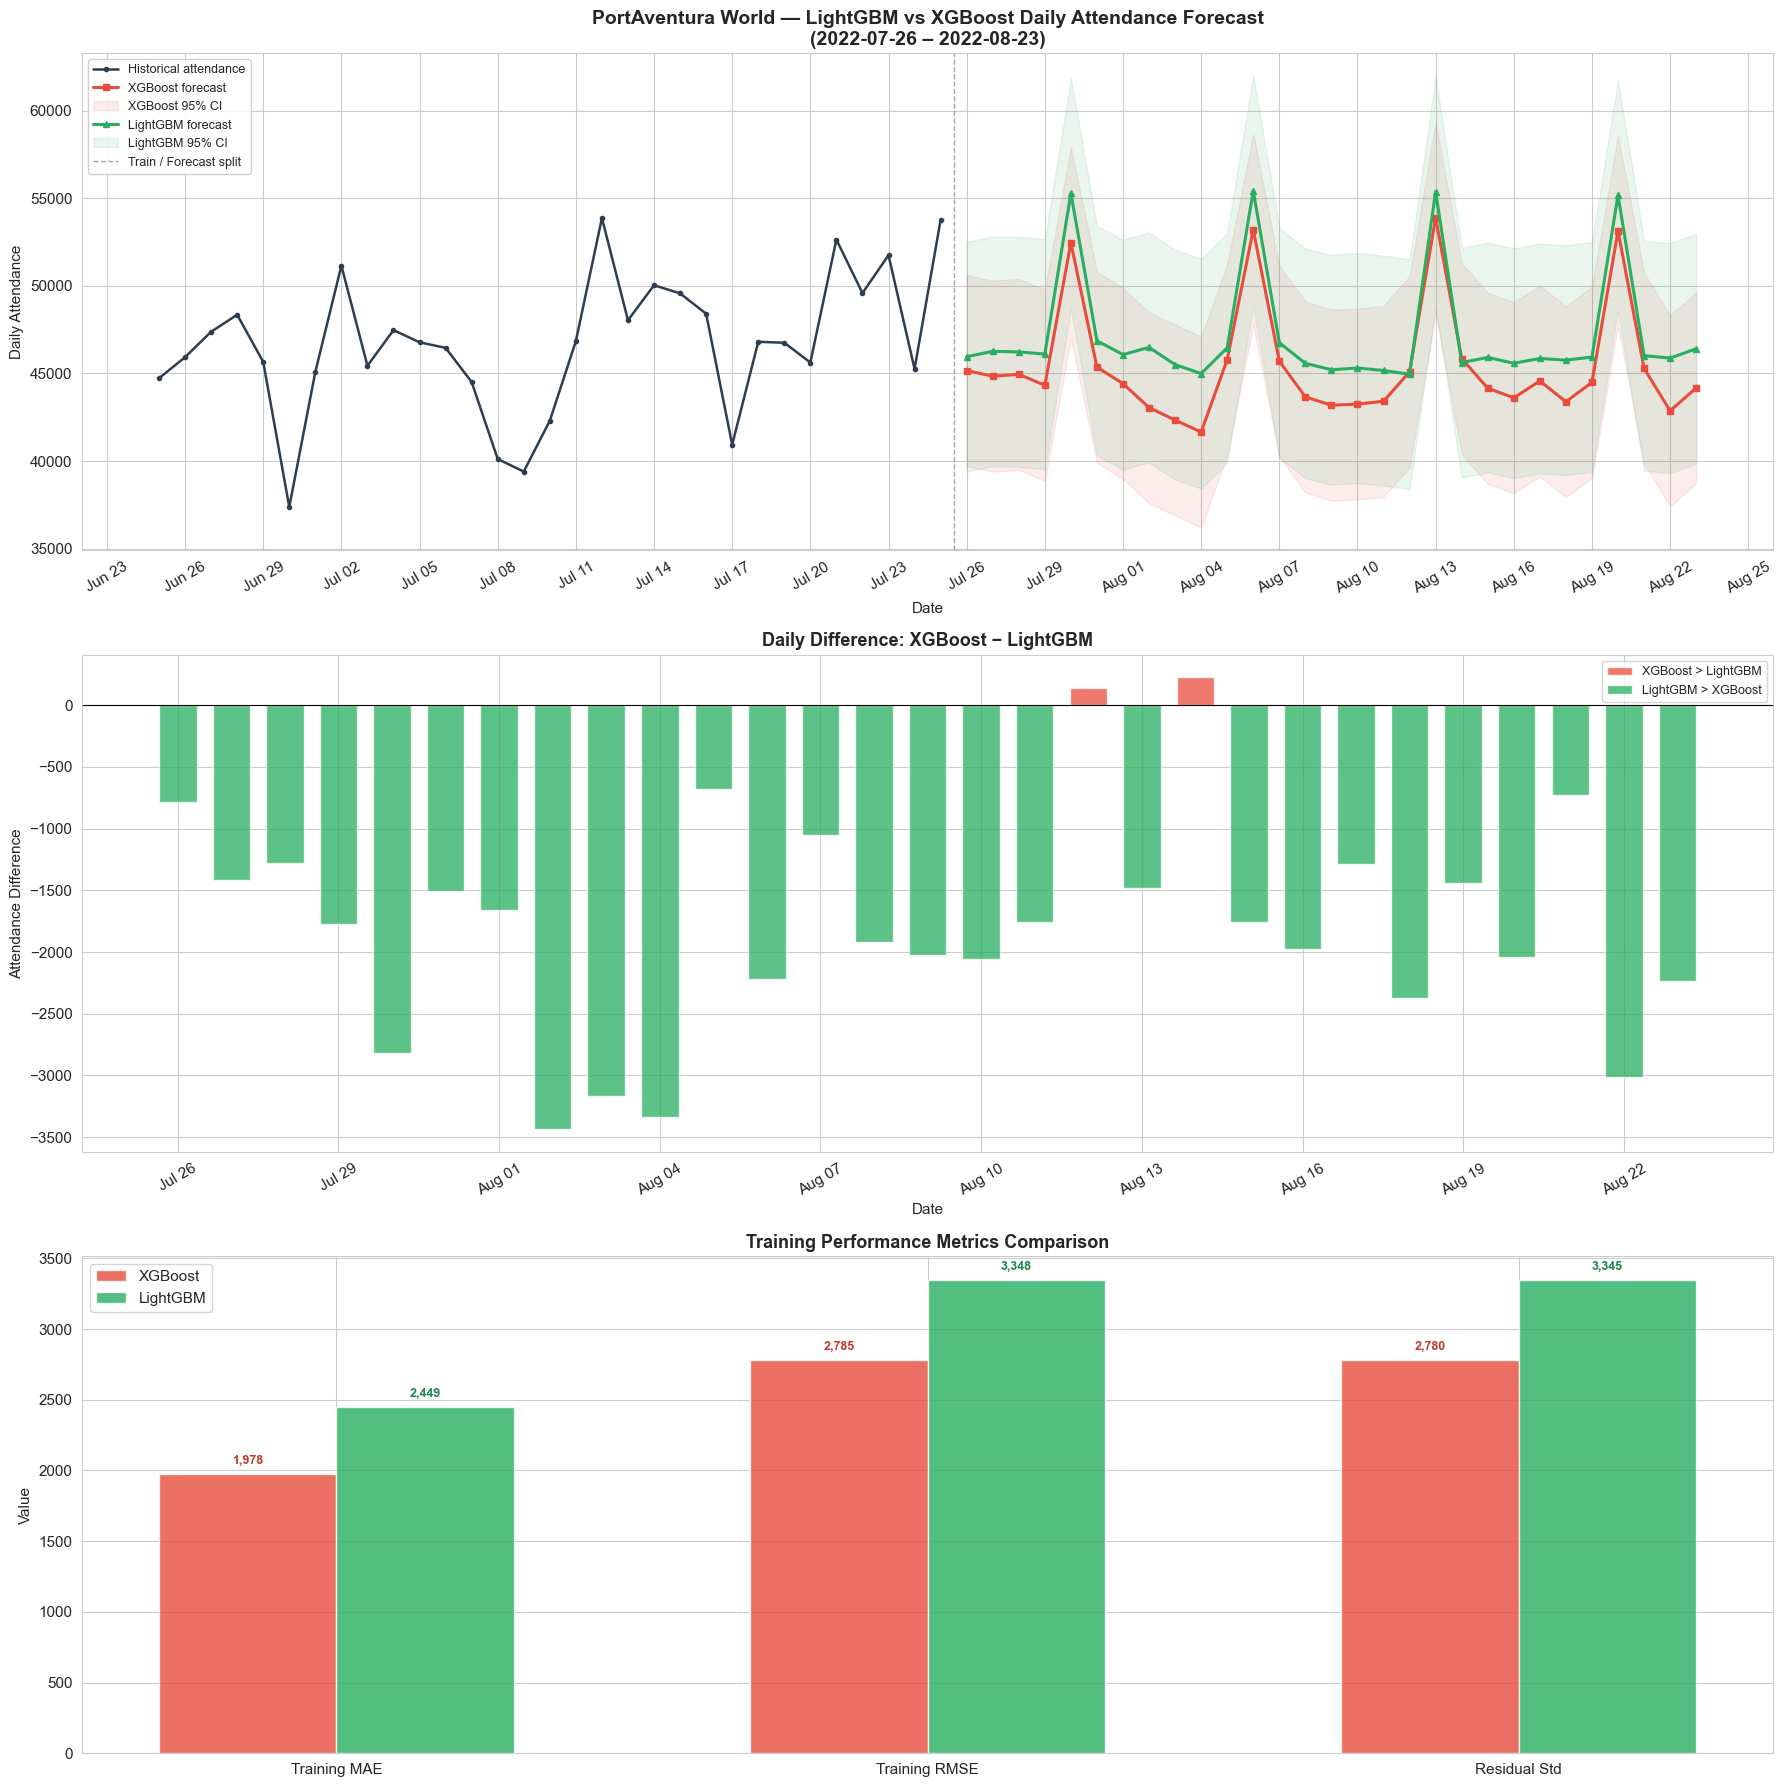

In [9]:
# ============================================================
# CELL 9 — COMPARISON VISUALIZATION
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(18, 18))

# ── SUBPLOT 1: Forecast comparison (both models on the same chart) ──
ax = axes[0]

# Historical attendance (last 30 days)
history_window = df.loc[CUTOFF - pd.Timedelta(days=30):CUTOFF, 'y']
ax.plot(history_window.index, history_window.values,
        color='#2c3e50', linewidth=1.8, marker='o', markersize=3,
        label='Historical attendance', zorder=3)

# XGBoost forecast
ax.plot(xgb_forecast['date'], xgb_forecast['predicted'],
        color='#e74c3c', linewidth=2.2, marker='s', markersize=5,
        label='XGBoost forecast', zorder=4)
ax.fill_between(xgb_forecast['date'],
                xgb_forecast['lower'], xgb_forecast['upper'],
                color='#e74c3c', alpha=0.10, label='XGBoost 95% CI', zorder=1)

# LightGBM forecast
ax.plot(lgb_forecast['date'], lgb_forecast['predicted'],
        color='#27ae60', linewidth=2.2, marker='^', markersize=5,
        label='LightGBM forecast', zorder=4)
ax.fill_between(lgb_forecast['date'],
                lgb_forecast['lower'], lgb_forecast['upper'],
                color='#27ae60', alpha=0.10, label='LightGBM 95% CI', zorder=1)

# Vertical cutoff line
ax.axvline(CUTOFF + pd.Timedelta(hours=12), color='grey',
           linestyle='--', linewidth=1, alpha=0.7, label='Train / Forecast split')

ax.set_title('PortAventura World — LightGBM vs XGBoost Daily Attendance Forecast\n'
             f'({FORECAST_START.date()} – {FORECAST_END.date()})', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Attendance')
ax.legend(loc='upper left', framealpha=0.9, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.tick_params(axis='x', rotation=30)

# ── SUBPLOT 2: Daily difference between models ──
ax2 = axes[1]
diff = xgb_forecast['predicted'].values - lgb_forecast['predicted'].values
colors = ['#e74c3c' if d > 0 else '#27ae60' for d in diff]
ax2.bar(xgb_forecast['date'], diff, color=colors, alpha=0.75, width=0.7)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Daily Difference: XGBoost − LightGBM', fontsize=13, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Attendance Difference')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax2.tick_params(axis='x', rotation=30)

# Add legend for bar colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', alpha=0.75, label='XGBoost > LightGBM'),
                   Patch(facecolor='#27ae60', alpha=0.75, label='LightGBM > XGBoost')]
ax2.legend(handles=legend_elements, loc='upper right', fontsize=9)

# ── SUBPLOT 3: Training metrics bar chart ──
ax3 = axes[2]
metrics_to_plot = ['Training MAE', 'Training RMSE', 'Residual Std']
x = np.arange(len(metrics_to_plot))
width = 0.30

xgb_vals = [metrics_df.loc['XGBoost', m] for m in metrics_to_plot]
lgb_vals = [metrics_df.loc['LightGBM', m] for m in metrics_to_plot]

bars1 = ax3.bar(x - width/2, xgb_vals, width, label='XGBoost', color='#e74c3c', alpha=0.8)
bars2 = ax3.bar(x + width/2, lgb_vals, width, label='LightGBM', color='#27ae60', alpha=0.8)

ax3.set_xticks(x)
ax3.set_xticklabels(metrics_to_plot, fontsize=11)
ax3.set_ylabel('Value')
ax3.set_title('Training Performance Metrics Comparison', fontsize=13, fontweight='bold')
ax3.legend(fontsize=11)

# Add value labels on bars
for bar in bars1:
    h = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., h + 50,
             f'{h:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#c0392b')
for bar in bars2:
    h = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., h + 50,
             f'{h:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1e8449')

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# CELL 10 — FINAL SUMMARY
# ============================================================

print("=" * 85)
print("  FINAL SUMMARY — LightGBM vs XGBoost")
print("=" * 85)
print(f"\n  {'Metric':<30} {'XGBoost':>15} {'LightGBM':>15} {'Winner':>15}")
print("  " + "-" * 75)

comparisons = [
    ('Training MAE', metrics_df.loc['XGBoost', 'Training MAE'], metrics_df.loc['LightGBM', 'Training MAE'], 'lower'),
    ('Training RMSE', metrics_df.loc['XGBoost', 'Training RMSE'], metrics_df.loc['LightGBM', 'Training RMSE'], 'lower'),
    ('Training R²', metrics_df.loc['XGBoost', 'Training R²'], metrics_df.loc['LightGBM', 'Training R²'], 'higher'),
    ('Training MAPE (%)', metrics_df.loc['XGBoost', 'Training MAPE (%)'], metrics_df.loc['LightGBM', 'Training MAPE (%)'], 'lower'),
    ('Residual Std', metrics_df.loc['XGBoost', 'Residual Std'], metrics_df.loc['LightGBM', 'Residual Std'], 'lower'),
    ('Best Iteration', metrics_df.loc['XGBoost', 'Best Iteration'], metrics_df.loc['LightGBM', 'Best Iteration'], None),
]

for name, xgb_v, lgb_v, direction in comparisons:
    if direction == 'lower':
        winner = 'XGBoost' if xgb_v < lgb_v else 'LightGBM' if lgb_v < xgb_v else 'Tie'
    elif direction == 'higher':
        winner = 'XGBoost' if xgb_v > lgb_v else 'LightGBM' if lgb_v > xgb_v else 'Tie'
    else:
        winner = '-'

    if isinstance(xgb_v, float):
        print(f"  {name:<30} {xgb_v:>15,.2f} {lgb_v:>15,.2f} {winner:>15}")
    else:
        print(f"  {name:<30} {xgb_v:>15} {lgb_v:>15} {winner:>15}")

print("  " + "-" * 75)

# Forecast-level comparison
print(f"\n  {'Forecast Metric':<30} {'XGBoost':>15} {'LightGBM':>15}")
print("  " + "-" * 60)
print(f"  {'Avg daily forecast':<30} {xgb_forecast['predicted'].mean():>15,.0f} {lgb_forecast['predicted'].mean():>15,.0f}")
print(f"  {'Total 29-day forecast':<30} {xgb_forecast['predicted'].sum():>15,.0f} {lgb_forecast['predicted'].sum():>15,.0f}")
print(f"  {'Forecast std (variability)':<30} {xgb_forecast['predicted'].std():>15,.0f} {lgb_forecast['predicted'].std():>15,.0f}")

if actual_jul26 is not None:
    print(f"\n  Jul 26 actual: {actual_jul26:,.0f}")
    print(f"  XGBoost prediction: {xgb_pred_jul26:,.0f} (MAPE: {xgb_mape:.2f}%)")
    print(f"  LightGBM prediction: {lgb_pred_jul26:,.0f} (MAPE: {lgb_mape:.2f}%)")

print("\n" + "=" * 85)

  FINAL SUMMARY — LightGBM vs XGBoost

  Metric                                 XGBoost        LightGBM          Winner
  ---------------------------------------------------------------------------
  Training MAE                          1,978.40        2,449.40         XGBoost
  Training RMSE                         2,784.69        3,347.71         XGBoost
  Training R²                               0.98            0.96         XGBoost
  Training MAPE (%)                       272.45          305.28         XGBoost
  Residual Std                          2,780.30        3,345.32         XGBoost
  Best Iteration                              71              72               -
  ---------------------------------------------------------------------------

  Forecast Metric                        XGBoost        LightGBM
  ------------------------------------------------------------
  Avg daily forecast                      45,426          47,179
  Total 29-day forecast                1,317

In [11]:
# ============================================================
# CELL 11 — SAVE FORECASTS
# ============================================================

os.makedirs(f'{DATA_DIR}/forecasts/daily', exist_ok=True)

lgb_forecast[['date', 'day_name', 'predicted', 'lower', 'upper']].to_csv(
    f'{DATA_DIR}/forecasts/daily/lightgbm_daily_oneweek.csv', index=False
)
print(f"LightGBM forecast saved to {DATA_DIR}/forecasts/daily/lightgbm_daily_oneweek.csv")

xgb_forecast[['date', 'day_name', 'predicted', 'lower', 'upper']].to_csv(
    f'{DATA_DIR}/forecasts/daily/xgboost_daily_oneweek.csv', index=False
)
print(f"XGBoost forecast saved to {DATA_DIR}/forecasts/daily/xgboost_daily_oneweek.csv")

LightGBM forecast saved to final_data/forecasts/lightgbm_daily_oneweek.csv
XGBoost forecast saved to final_data/forecasts/xgboost_daily_oneweek.csv
